import the required libraries 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Load the netflix dataset

In [3]:

df = pd.read_csv("C:\\Users\\tavva\\Downloads\\netflix_titles.csv (2)\\netflix_titles.csv")

head gives the first 5 rows in the dataset

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


It gives the number of rows and columns in dataset

In [5]:

print("Dataset shape:", df.shape)


Dataset shape: (8807, 12)


To display all column names in dataset

In [6]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')


check the datatypes and non null values for columns
gives the all statistics of given dataset 

In [7]:
df.info()
display(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


check if it has missing values in each column

In [8]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


check if it has any duplicate rows

In [9]:
print(df.duplicated().sum())

0


for target variable rating count the records for each category

In [10]:
print(df["rating"].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


remove rows with invalid categories and null values

In [11]:
df = df.dropna(subset=["rating"])
invalid_ratings = ["74 min", "84 min", "66 min"]

df = df[~df["rating"].isin(invalid_ratings)]

df.shape


(8800, 12)

final number of rows and columns after cleaning

In [12]:
print("Dataset shape:", df.shape)

Dataset shape: (8800, 12)


fill the missing values as unknown for every column

In [13]:
# Fill missing values

df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["date_added"] = df["date_added"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


take input features as x and rating column as target y

In [14]:
X = df[[
    "type",
    "country",
    "release_year",
    "duration",
    "listed_in"
]]

y = df["rating"]

print("X:")
print(X.head())

print("\ny:")
y.head()

X:
      type        country  release_year   duration  \
0    Movie  United States          2020     90 min   
1  TV Show   South Africa          2021  2 Seasons   
2  TV Show        Unknown          2021   1 Season   
3  TV Show        Unknown          2021   1 Season   
4  TV Show          India          2021  2 Seasons   

                                           listed_in  
0                                      Documentaries  
1    International TV Shows, TV Dramas, TV Mysteries  
2  Crime TV Shows, International TV Shows, TV Act...  
3                             Docuseries, Reality TV  
4  International TV Shows, Romantic TV Shows, TV ...  

y:


0    PG-13
1    TV-MA
2    TV-MA
3    TV-MA
4    TV-MA
Name: rating, dtype: str

convert categorical data into numerical data using one hot encoding

In [15]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore")
X_encoded = encoder.fit_transform(X)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

Original shape: (8800, 5)
Encoded shape: (8800, 1559)


split the dataset into training data and testing data

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7040, 1559)
Testing data: (1760, 1559)


train the three models and check their accuracy,recall,precision and f1 score

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Logistic Regression
lr_normal = LogisticRegression(max_iter=1000, random_state=42)
lr_normal.fit(X_train, y_train)
lr_normal_pred = lr_normal.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_normal_pred)
lr_precision = precision_score(y_test, lr_normal_pred, average="weighted", zero_division=0)
lr_recall = recall_score(y_test, lr_normal_pred, average="weighted", zero_division=0)
lr_f1 = f1_score(y_test, lr_normal_pred, average="weighted", zero_division=0)


# 2. Decision Tree
dt_normal = DecisionTreeClassifier(random_state=42)
dt_normal.fit(X_train, y_train)
dt_normal_pred = dt_normal.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_normal_pred)
dt_precision = precision_score(y_test, dt_normal_pred, average="weighted", zero_division=0)
dt_recall = recall_score(y_test, dt_normal_pred, average="weighted", zero_division=0)
dt_f1 = f1_score(y_test, dt_normal_pred, average="weighted", zero_division=0)


# 3. Random Forest
rf_normal = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_normal.fit(X_train, y_train)
rf_normal_pred = rf_normal.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_normal_pred)
rf_precision = precision_score(y_test, rf_normal_pred, average="weighted", zero_division=0)
rf_recall = recall_score(y_test, rf_normal_pred, average="weighted", zero_division=0)
rf_f1 = f1_score(y_test, rf_normal_pred, average="weighted", zero_division=0)


# Display results
print("Model Performance")
print("-----------------------------")

print(f"Logistic Regression")
print(f"Accuracy  : {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"Precision : {lr_precision:.4f} ({lr_precision*100:.2f}%)")
print(f"Recall    : {lr_recall:.4f} ({lr_recall*100:.2f}%)")
print(f"F1 Score  : {lr_f1:.4f} ({lr_f1*100:.2f}%)")

print("\nDecision Tree")
print(f"Accuracy  : {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"Precision : {dt_precision:.4f} ({dt_precision*100:.2f}%)")
print(f"Recall    : {dt_recall:.4f} ({dt_recall*100:.2f}%)")
print(f"F1 Score  : {dt_f1:.4f} ({dt_f1*100:.2f}%)")

print("\nRandom Forest")
print(f"Accuracy  : {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision : {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"Recall    : {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f"F1 Score  : {rf_f1:.4f} ({rf_f1*100:.2f}%)")

Model Performance
-----------------------------
Logistic Regression
Accuracy  : 0.5403 (54.03%)
Precision : 0.5175 (51.75%)
Recall    : 0.5403 (54.03%)
F1 Score  : 0.5170 (51.70%)

Decision Tree
Accuracy  : 0.4824 (48.24%)
Precision : 0.4722 (47.22%)
Recall    : 0.4824 (48.24%)
F1 Score  : 0.4753 (47.53%)

Random Forest
Accuracy  : 0.5159 (51.59%)
Precision : 0.4871 (48.71%)
Recall    : 0.5159 (51.59%)
F1 Score  : 0.4922 (49.22%)


compare and choose the best model based on weighted f1 score before regularization

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd

# Predictions
lr_pred = lr_normal.predict(X_test)
dt_pred = dt_normal.predict(X_test)
rf_pred = rf_normal.predict(X_test)


# Calculate Weighted F1 Score
lr_f1 = f1_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)

dt_f1 = f1_score(
    y_test, dt_pred,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)


# Comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Weighted F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

print("\nWeighted F1 Score Comparison:")
print(comparison)


# Find the best model
f1_scores = {
    "Logistic Regression": lr_f1,
    "Decision Tree": dt_f1,
    "Random Forest": rf_f1
}

best_model = max(f1_scores, key=f1_scores.get)
best_f1 = f1_scores[best_model]

print("\nBest Model:")
print(best_model)
print(f"Weighted F1 Score: {best_f1:.4f}")





Weighted F1 Score Comparison:
                 Model  Weighted F1 Score
0  Logistic Regression           0.517021
1        Decision Tree           0.475257
2        Random Forest           0.492205

Best Model:
Logistic Regression
Weighted F1 Score: 0.5170


regularization is used to reduce overfitting

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# 1. Regularized Logistic Regression
lr_reg = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

lr_reg.fit(X_train, y_train)
lr_reg_pred = lr_reg.predict(X_test)

lr_reg_accuracy = accuracy_score(y_test, lr_reg_pred)
lr_reg_precision = precision_score(
    y_test, lr_reg_pred, average="weighted", zero_division=0
)
lr_reg_recall = recall_score(
    y_test, lr_reg_pred, average="weighted", zero_division=0
)
lr_reg_f1 = f1_score(
    y_test, lr_reg_pred, average="weighted", zero_division=0
)


# 2. Regularized Decision Tree
dt_reg = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    ccp_alpha=0.001,
    random_state=42
)

dt_reg.fit(X_train, y_train)
dt_reg_pred = dt_reg.predict(X_test)

dt_reg_accuracy = accuracy_score(y_test, dt_reg_pred)
dt_reg_precision = precision_score(
    y_test, dt_reg_pred, average="weighted", zero_division=0
)
dt_reg_recall = recall_score(
    y_test, dt_reg_pred, average="weighted", zero_division=0
)
dt_reg_f1 = f1_score(
    y_test, dt_reg_pred, average="weighted", zero_division=0
)


# 3. Regularized Random Forest
rf_reg = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)
rf_reg_pred = rf_reg.predict(X_test)

rf_reg_accuracy = accuracy_score(y_test, rf_reg_pred)
rf_reg_precision = precision_score(
    y_test, rf_reg_pred, average="weighted", zero_division=0
)
rf_reg_recall = recall_score(
    y_test, rf_reg_pred, average="weighted", zero_division=0
)
rf_reg_f1 = f1_score(
    y_test, rf_reg_pred, average="weighted", zero_division=0
)


# Display results
print("Regularized Models Performance")
print("--------------------------------------------------")

print("\nLogistic Regression")
print(f"Accuracy  : {lr_reg_accuracy:.4f} ({lr_reg_accuracy*100:.2f}%)")
print(f"Precision : {lr_reg_precision:.4f} ({lr_reg_precision*100:.2f}%)")
print(f"Recall    : {lr_reg_recall:.4f} ({lr_reg_recall*100:.2f}%)")
print(f"F1 Score  : {lr_reg_f1:.4f} ({lr_reg_f1*100:.2f}%)")

print("\nDecision Tree")
print(f"Accuracy  : {dt_reg_accuracy:.4f} ({dt_reg_accuracy*100:.2f}%)")
print(f"Precision : {dt_reg_precision:.4f} ({dt_reg_precision*100:.2f}%)")
print(f"Recall    : {dt_reg_recall:.4f} ({dt_reg_recall*100:.2f}%)")
print(f"F1 Score  : {dt_reg_f1:.4f} ({dt_reg_f1*100:.2f}%)")

print("\nRandom Forest")
print(f"Accuracy  : {rf_reg_accuracy:.4f} ({rf_reg_accuracy*100:.2f}%)")
print(f"Precision : {rf_reg_precision:.4f} ({rf_reg_precision*100:.2f}%)")
print(f"Recall    : {rf_reg_recall:.4f} ({rf_reg_recall*100:.2f}%)")
print(f"F1 Score  : {rf_reg_f1:.4f} ({rf_reg_f1*100:.2f}%)")

Regularized Models Performance
--------------------------------------------------

Logistic Regression
Accuracy  : 0.5403 (54.03%)
Precision : 0.5175 (51.75%)
Recall    : 0.5403 (54.03%)
F1 Score  : 0.5170 (51.70%)

Decision Tree
Accuracy  : 0.4869 (48.69%)
Precision : 0.4679 (46.79%)
Recall    : 0.4869 (48.69%)
F1 Score  : 0.4203 (42.03%)

Random Forest
Accuracy  : 0.2824 (28.24%)
Precision : 0.5432 (54.32%)
Recall    : 0.2824 (28.24%)
F1 Score  : 0.3312 (33.12%)


In [21]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_reg_accuracy,
        dt_reg_accuracy,
        rf_reg_accuracy
    ],
    "Precision": [
        lr_reg_precision,
        dt_reg_precision,
        rf_reg_precision
    ],
    "Recall": [
        lr_reg_recall,
        dt_reg_recall,
        rf_reg_recall
    ],
    "F1 Score": [
        lr_reg_f1,
        dt_reg_f1,
        rf_reg_f1
    ]
})

print("\nModel Comparison")
print(results.round(4))


Model Comparison
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.5403     0.5175  0.5403    0.5170
1        Decision Tree    0.4869     0.4679  0.4869    0.4203
2        Random Forest    0.2824     0.5432  0.2824    0.3312


In [22]:
from sklearn.metrics import f1_score

# Predictions after regularization
lr_reg_pred = lr_reg.predict(X_test)
dt_reg_pred = dt_reg.predict(X_test)
rf_reg_pred = rf_reg.predict(X_test)

# Weighted F1 scores
lr_f1 = f1_score(y_test, lr_reg_pred, average="weighted", zero_division=0)
dt_f1 = f1_score(y_test, dt_reg_pred, average="weighted", zero_division=0)
rf_f1 = f1_score(y_test, rf_reg_pred, average="weighted", zero_division=0)

# Store scores
models = {
    "Logistic Regression": lr_f1,
    "Decision Tree": dt_f1,
    "Random Forest": rf_f1
}

# Find best model
best_model = max(models, key=models.get)

print("Weighted F1 Scores:")
for model, score in models.items():
    print(f"{model}: {score:.4f}")

print("\nBest Model After Regularization:")
print(best_model)
print(f"Weighted F1 Score: {models[best_model]:.4f}")

Weighted F1 Scores:
Logistic Regression: 0.5170
Decision Tree: 0.4203
Random Forest: 0.3312

Best Model After Regularization:
Logistic Regression
Weighted F1 Score: 0.5170


plot the three models based on accuracy,precision,recall and f1 score

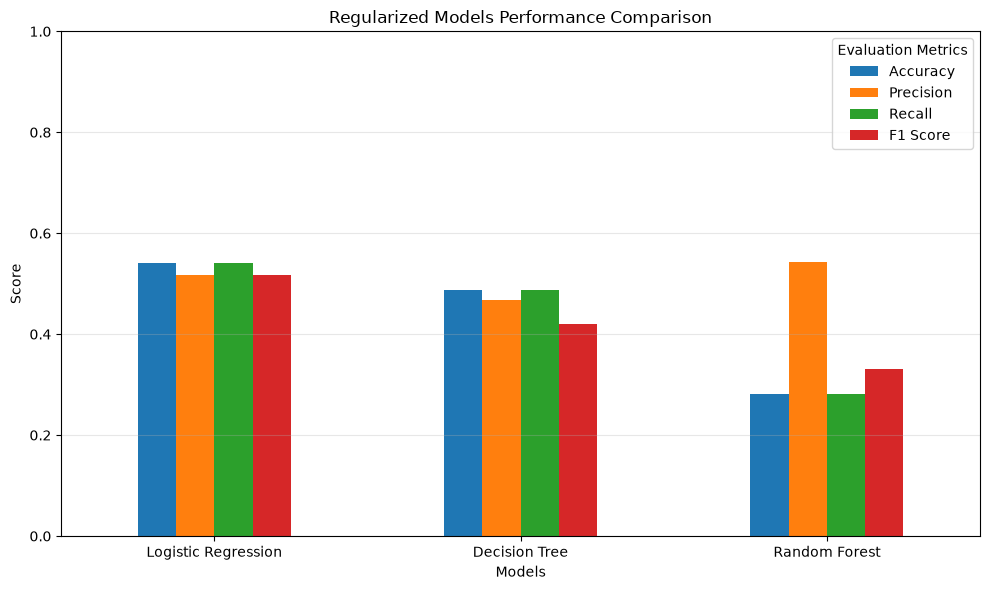

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison DataFrame
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_reg_accuracy,
        dt_reg_accuracy,
        rf_reg_accuracy
    ],
    "Precision": [
        lr_reg_precision,
        dt_reg_precision,
        rf_reg_precision
    ],
    "Recall": [
        lr_reg_recall,
        dt_reg_recall,
        rf_reg_recall
    ],
    "F1 Score": [
        lr_reg_f1,
        dt_reg_f1,
        rf_reg_f1
    ]
})

# Plot
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Regularized Models Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metrics")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

calculate TP,TN,FP and FN for each model

In [24]:
from sklearn.metrics import confusion_matrix

positive_class = "TV-MA"
X_all = X_encoded
y_all = y
y_all_binary = (y_all == positive_class).astype(int)

def get_all_data_counts(predictions):
    pred_binary = (predictions == positive_class).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_all_binary, pred_binary, labels=[0, 1]
    ).ravel()
    return int(tp), int(fp), int(fn), int(tn)

lr_all_pred = lr_reg.predict(X_all)
dt_all_pred = dt_reg.predict(X_all)
rf_all_pred = rf_reg.predict(X_all)

tp_lr, fp_lr, fn_lr, tn_lr = get_all_data_counts(lr_all_pred)
tp_dt, fp_dt, fn_dt, tn_dt = get_all_data_counts(dt_all_pred)
tp_rf, fp_rf, fn_rf, tn_rf = get_all_data_counts(rf_all_pred)

cf_comparison_all = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "TP": [tp_lr, tp_dt, tp_rf],
    "FP": [fp_lr, fp_dt, fp_rf],
    "FN": [fn_lr, fn_dt, fn_rf],
    "TN": [tn_lr, tn_dt, tn_rf]
})

cf_comparison_all["Total"] = (
    cf_comparison_all["TP"] + cf_comparison_all["FP"] +
    cf_comparison_all["FN"] + cf_comparison_all["TN"]
)

print("Positive class:", positive_class)
print("Total dataset samples:", len(y_all))
display(cf_comparison_all)

assert all(cf_comparison_all["Total"] == len(y_all))


Positive class: TV-MA
Total dataset samples: 8800


,Model,TP,FP,FN,TN,Total
0,Logistic Regression,2557,1401,650,4192,8800
1,Decision Tree,2781,3073,426,2520,8800
2,Random Forest,700,163,2507,5430,8800


Display the Confusion Matrices

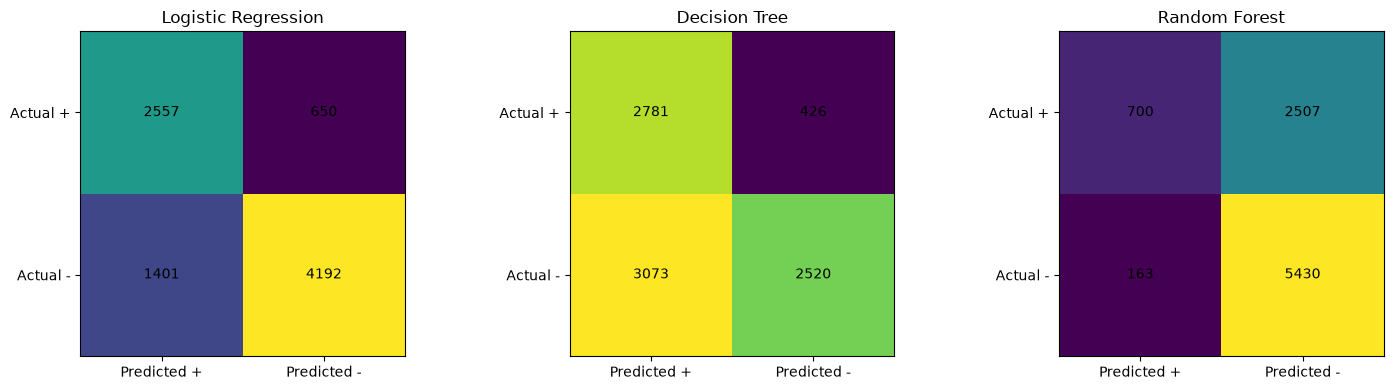

In [25]:
matrices = {
    "Logistic Regression": [[tp_lr, fn_lr], [fp_lr, tn_lr]],
    "Decision Tree": [[tp_dt, fn_dt], [fp_dt, tn_dt]],
    "Random Forest": [[tp_rf, fn_rf], [fp_rf, tn_rf]]
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, matrix) in zip(axes, matrices.items()):
    ax.imshow(matrix)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Predicted +", "Predicted -"])
    ax.set_yticklabels(["Actual +", "Actual -"])
    ax.set_title(name)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, matrix[i][j], ha="center", va="center")
plt.tight_layout()
plt.show()


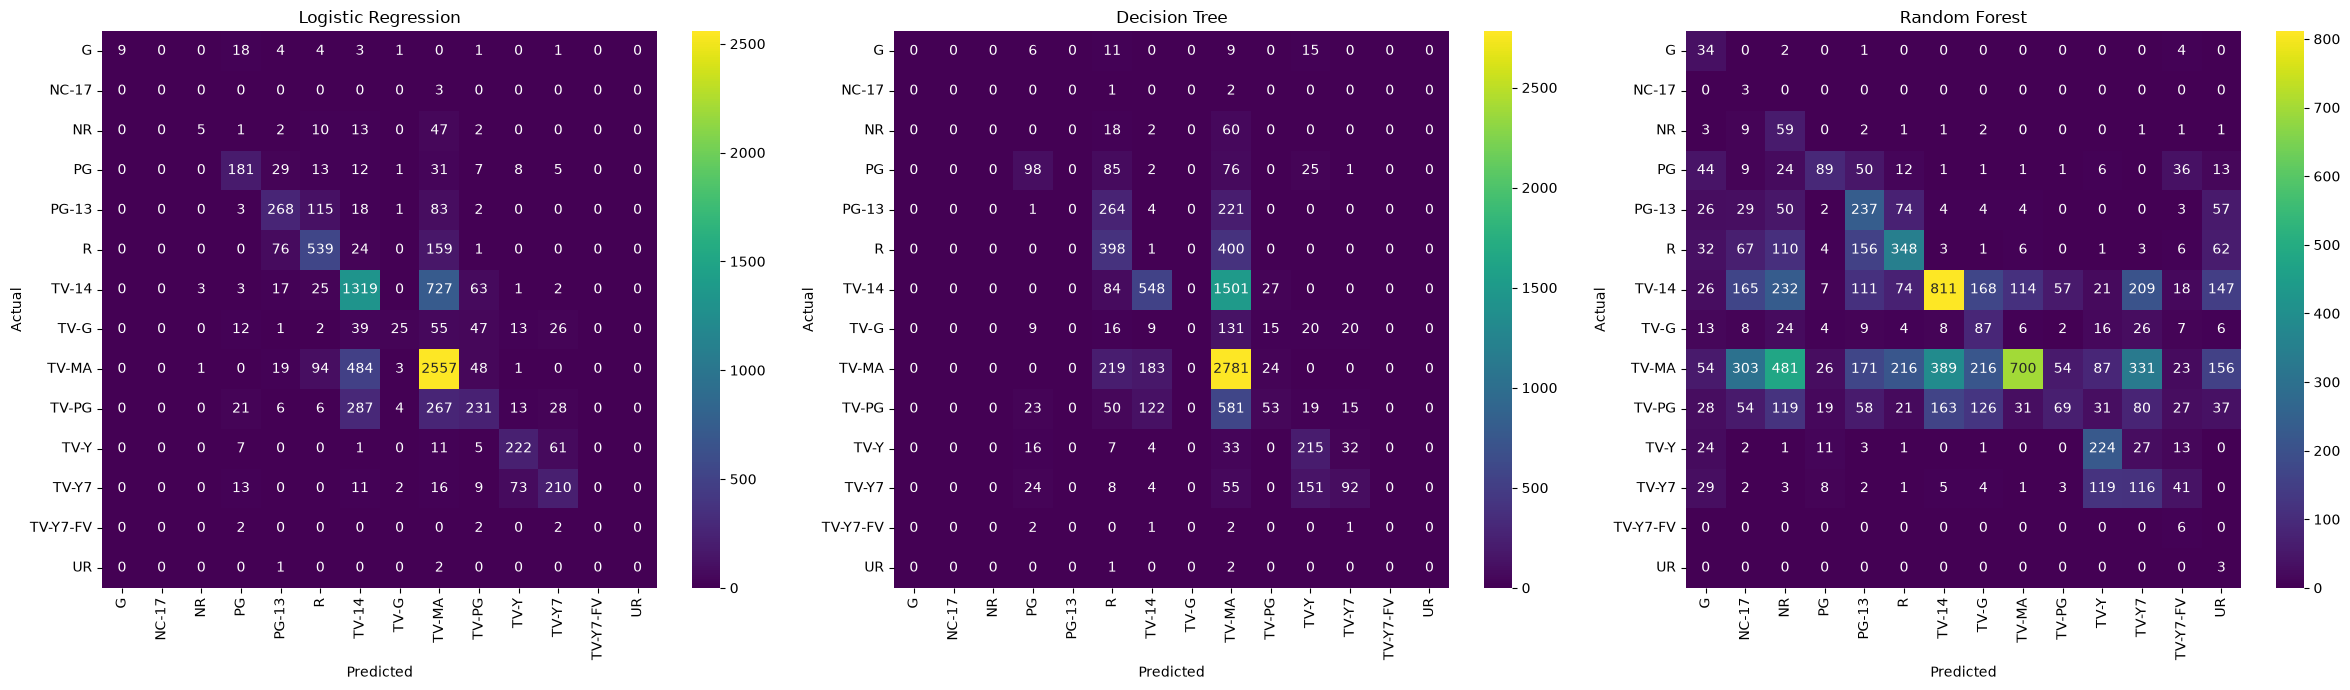

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use the complete dataset
X_all = X_encoded
y_all = y

# Predictions on the complete dataset
lr_all_pred = lr_reg.predict(X_all)
dt_all_pred = dt_reg.predict(X_all)
rf_all_pred = rf_reg.predict(X_all)

# Get all rating classes
labels = sorted(y_all.unique())

# Confusion matrices
cm_lr = confusion_matrix(y_all, lr_all_pred, labels=labels)
cm_dt = confusion_matrix(y_all, dt_all_pred, labels=labels)
cm_rf = confusion_matrix(y_all, rf_all_pred, labels=labels)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[2]
)
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()